# Model generalization 
### Classification case 

In [25]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
# ANN - MLP 
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

In [26]:
def plot_decision_boundary(model, X, y, title="Model", resolution=300):

    n_features = model.n_features_in_

    # ---- 1D ----
    if n_features == 1:
        xs = np.linspace(X.min()-1, X.max()+1, resolution).reshape(-1,1)

        if hasattr(model, "predict_proba"):
            preds = model.predict_proba(xs)[:,1]
        else:
            preds = model.predict(xs)

        plt.figure(figsize=(6,4))
        plt.scatter(X[:,0], y, c=y, cmap="coolwarm", s=25)
        plt.plot(xs, preds, color="black", linewidth=2)
        plt.title(title)
        plt.show()
        return

    # ---- 2D ----
    if n_features == 2:
        x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
        y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

        xx, yy = np.meshgrid(
            np.linspace(x_min, x_max, resolution),
            np.linspace(y_min, y_max, resolution)
        )

        grid = np.c_[xx.ravel(), yy.ravel()]
        Z = model.predict(grid).reshape(xx.shape)

        plt.figure(figsize=(6,5))
        plt.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
        plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", edgecolor="k")
        plt.title(title)
        plt.show()

In [27]:
# Data 
X,y = make_blobs(n_samples=33,centers=2,cluster_std=2.0,random_state=4)

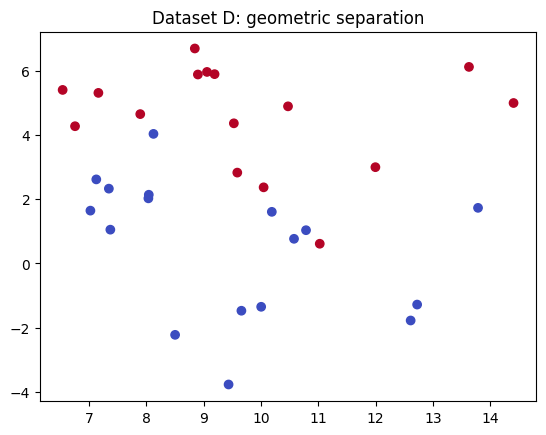

In [28]:
plt.scatter(X[:,0],X[:,1],c=y,cmap="coolwarm")
plt.title("Dataset D: geometric separation")
plt.show()

In [29]:
Xtr,Xte,Ytr,Yte = train_test_split(X,y,test_size=0.3)

In [30]:
mlp = MLPClassifier(hidden_layer_sizes=(20,20),max_iter=2000)
mlp.fit(Xtr,Ytr)

MLPClassifier(hidden_layer_sizes=(20, 20), max_iter=2000)

In [31]:
pred = mlp.predict(Xte)
print("Testing accuracy:", accuracy_score(Yte,pred) * 100)

Testing accuracy: 80.0


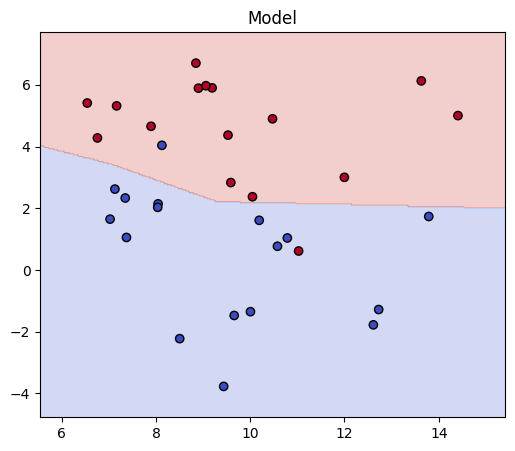

In [32]:
# plot 
plot_decision_boundary(mlp, X, y,"Model")